In [ ]:
!pip install timm faiss-cpu scikit-learn

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

import timm
import faiss

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_dir = "/content/drive/MyDrive/VISICLEAN/Airbnb Data/Training Data"
test_dir = "/content/drive/MyDrive/VISICLEAN/Airbnb Data/Test Data"

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
class TripletDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.transform = transform
        self.class_to_images = {}

        for folder in os.listdir(root_dir):

            folder_path = os.path.join(root_dir,folder)

            if os.path.isdir(folder_path):

                self.class_to_images[folder] = [
                    os.path.join(folder_path,img)
                    for img in os.listdir(folder_path)
                ]

        self.classes = list(self.class_to_images.keys())

    def __len__(self):
        return sum(len(v) for v in self.class_to_images.values())

    def __getitem__(self, idx):

        anchor_class = np.random.choice(self.classes)

        anchor_path = np.random.choice(self.class_to_images[anchor_class])
        positive_path = np.random.choice(self.class_to_images[anchor_class])

        negative_class = np.random.choice(
            [c for c in self.classes if c != anchor_class]
        )

        negative_path = np.random.choice(self.class_to_images[negative_class])

        anchor = Image.open(anchor_path).convert("RGB")
        positive = Image.open(positive_path).convert("RGB")
        negative = Image.open(negative_path).convert("RGB")

        if self.transform:

            anchor = self.transform(anchor)
            positive = self.transform(positive)
            negative = self.transform(negative)

        return anchor, positive, negative

In [ ]:
train_dataset = TripletDataset(train_dir, transform)
test_dataset = TripletDataset(test_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
class DupliGoneModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.backbone = timm.create_model(
            "efficientnet_b4",
            pretrained=True,
            num_classes=0
        )

        self.embedding = nn.Sequential(
            nn.Linear(1792,512),
            nn.ReLU(),
            nn.Linear(512,128)
        )

        self.hash_layer = nn.Linear(128,64)

    def forward_once(self,x):

        x = self.backbone(x)

        x = self.embedding(x)

        x = F.normalize(x,p=2,dim=1)

        hash_code = torch.tanh(self.hash_layer(x))

        return hash_code

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DupliGoneModel().to(device)

optimizer = optim.Adam(model.parameters(),lr=3e-5)

criterion = nn.TripletMarginLoss(margin=1.0)

In [ ]:
epochs = 30

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for anchor,positive,negative in train_loader:

        anchor = anchor.to(device)
        positive = positive.to(device)
        negative = negative.to(device)

        optimizer.zero_grad()

        anchor_emb = model.forward_once(anchor)
        pos_emb = model.forward_once(positive)
        neg_emb = model.forward_once(negative)

        loss = criterion(anchor_emb,pos_emb,neg_emb)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Epoch:",epoch+1,"Loss:",total_loss/len(train_loader))

Epoch: 1 Loss: 0.8294705927371979
Epoch: 2 Loss: 0.549167363345623
Epoch: 3 Loss: 0.37616037484258413
Epoch: 4 Loss: 0.26878491751849654
Epoch: 5 Loss: 0.2288924738764763
Epoch: 6 Loss: 0.17859442625194788
Epoch: 7 Loss: 0.1815875006839633
Epoch: 8 Loss: 0.16172262635082008
Epoch: 9 Loss: 0.15772305838763714
Epoch: 10 Loss: 0.17528933780267836
Epoch: 11 Loss: 0.15906775621697306
Epoch: 12 Loss: 0.17567823659628629
Epoch: 13 Loss: 0.15145904365926982
Epoch: 14 Loss: 0.17096472959965467
Epoch: 15 Loss: 0.13841382153332232
Epoch: 16 Loss: 0.13663247544318438
Epoch: 17 Loss: 0.15094232708215713
Epoch: 18 Loss: 0.13231939570978285
Epoch: 19 Loss: 0.11132696643471718
Epoch: 20 Loss: 0.13497417457401753
Epoch: 21 Loss: 0.09915300216525794
Epoch: 22 Loss: 0.11266430113464594
Epoch: 23 Loss: 0.09273486817255616
Epoch: 24 Loss: 0.09392063161358237
Epoch: 25 Loss: 0.06876150676980615
Epoch: 26 Loss: 0.06887343721464276
Epoch: 27 Loss: 0.0635590696707368
Epoch: 28 Loss: 0.07853597328066826
Epoch: 

In [ ]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/dupligone_final_model.pth"
)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
embeddings = []
image_paths = []

model.eval()

with torch.no_grad():

    for folder in os.listdir(test_dir):

        folder_path = os.path.join(test_dir,folder)

        if os.path.isdir(folder_path):

            for img_name in os.listdir(folder_path):

                img_path = os.path.join(folder_path,img_name)

                image = Image.open(img_path).convert("RGB")

                image = transform(image).unsqueeze(0).to(device)

                emb = model.forward_once(image)

                embeddings.append(emb.cpu().numpy())

                image_paths.append(img_path)

embeddings = np.vstack(embeddings)

In [ ]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(embeddings)

print("FAISS index built with",index.ntotal,"images")

FAISS index built with 233 images


In [ ]:
query_embedding = embeddings[0].reshape(1,-1)

distances,indices = index.search(query_embedding,5)

print("Top 5 similar images:")

for i in indices[0]:
    print(image_paths[i])

Top 5 similar images:
/content/drive/MyDrive/VISICLEAN/Airbnb Data/Test Data/kitchen/berlin_13508386_2.jpg
/content/drive/MyDrive/VISICLEAN/Airbnb Data/Test Data/bedroom/berlin_28510664_2.jpg
/content/drive/MyDrive/VISICLEAN/Airbnb Data/Test Data/living-room/berlin_16014791_2.jpg
/content/drive/MyDrive/VISICLEAN/Airbnb Data/Test Data/bedroom/berlin_13755615_1.jpg
/content/drive/MyDrive/VISICLEAN/Airbnb Data/Test Data/bedroom/berlin_274072_2.jpg


In [ ]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_true = []
y_pred = []

threshold = 0.7   # similarity threshold

In [ ]:
model.eval()

with torch.no_grad():

    for folder in os.listdir(test_dir):

        folder_path = os.path.join(test_dir, folder)

        if not os.path.isdir(folder_path):
            continue

        images = os.listdir(folder_path)

        for i in range(len(images)-1):

            img1_path = os.path.join(folder_path, images[i])
            img2_path = os.path.join(folder_path, images[i+1])

            img1 = Image.open(img1_path).convert("RGB")
            img2 = Image.open(img2_path).convert("RGB")

            img1 = transform(img1).unsqueeze(0).to(device)
            img2 = transform(img2).unsqueeze(0).to(device)

            emb1 = model.forward_once(img1)
            emb2 = model.forward_once(img2)

            similarity = torch.cosine_similarity(emb1, emb2).item()

            pred = 1 if similarity > threshold else 0

            y_pred.append(pred)
            y_true.append(1)

In [ ]:
folders = os.listdir(test_dir)

for i in range(len(folders)-1):

    folder1 = os.path.join(test_dir, folders[i])
    folder2 = os.path.join(test_dir, folders[i+1])

    if not os.path.isdir(folder1) or not os.path.isdir(folder2):
        continue

    img1_path = os.path.join(folder1, os.listdir(folder1)[0])
    img2_path = os.path.join(folder2, os.listdir(folder2)[0])

    img1 = transform(Image.open(img1_path).convert("RGB")).unsqueeze(0).to(device)
    img2 = transform(Image.open(img2_path).convert("RGB")).unsqueeze(0).to(device)

    emb1 = model.forward_once(img1)
    emb2 = model.forward_once(img2)

    similarity = torch.cosine_similarity(emb1, emb2).item()

    pred = 1 if similarity > threshold else 0

    y_pred.append(pred)
    y_true.append(0)

In [ ]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9094827586206896
Precision: 0.9952153110047847
Recall: 0.9122807017543859
F1 Score: 0.9519450800915332


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [ ]:
y_true = []
y_scores = []

model.eval()

with torch.no_grad():

    for folder in os.listdir(test_dir):

        folder_path = os.path.join(test_dir, folder)

        if not os.path.isdir(folder_path):
            continue

        images = os.listdir(folder_path)

        for i in range(len(images)-1):

            img1_path = os.path.join(folder_path, images[i])
            img2_path = os.path.join(folder_path, images[i+1])

            img1 = transform(Image.open(img1_path).convert("RGB")).unsqueeze(0).to(device)
            img2 = transform(Image.open(img2_path).convert("RGB")).unsqueeze(0).to(device)

            emb1 = model.forward_once(img1)
            emb2 = model.forward_once(img2)

            similarity = torch.cosine_similarity(emb1, emb2).item()

            y_scores.append(similarity)
            y_true.append(1)

In [ ]:
folders = os.listdir(test_dir)

for i in range(len(folders)-1):

    folder1 = os.path.join(test_dir, folders[i])
    folder2 = os.path.join(test_dir, folders[i+1])

    if not os.path.isdir(folder1) or not os.path.isdir(folder2):
        continue

    img1_path = os.path.join(folder1, os.listdir(folder1)[0])
    img2_path = os.path.join(folder2, os.listdir(folder2)[0])

    img1 = transform(Image.open(img1_path).convert("RGB")).unsqueeze(0).to(device)
    img2 = transform(Image.open(img2_path).convert("RGB")).unsqueeze(0).to(device)

    emb1 = model.forward_once(img1)
    emb2 = model.forward_once(img2)

    similarity = torch.cosine_similarity(emb1, emb2).item()

    y_scores.append(similarity)
    y_true.append(0)

In [ ]:
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

AUC Score: 0.9035087719298246


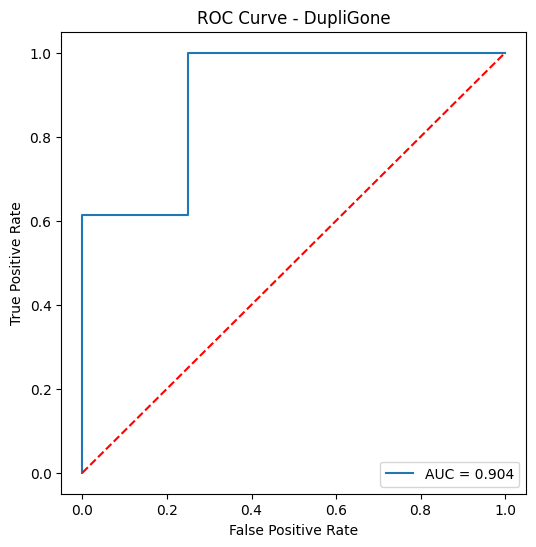

In [ ]:
plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - DupliGone")

plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

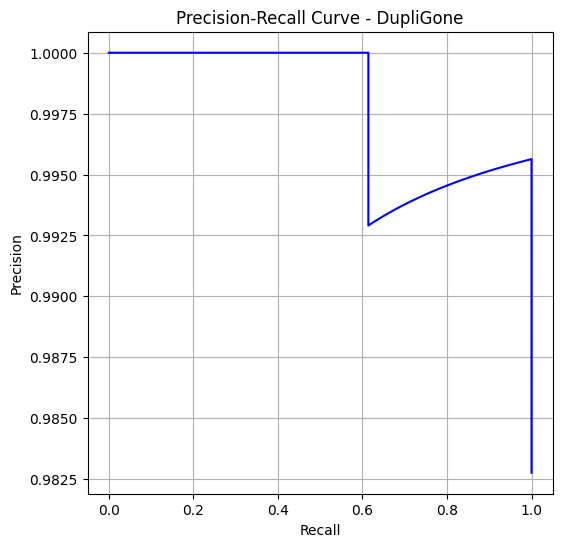

In [ ]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_true, y_scores)

plt.figure(figsize=(6,6))

plt.plot(recall_vals, precision_vals, color='blue')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - DupliGone")

plt.grid(True)

plt.show()

In [ ]:
threshold = 0.7

y_pred = [1 if score > threshold else 0 for score in y_scores]

In [ ]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[  3   1]
 [ 20 208]]


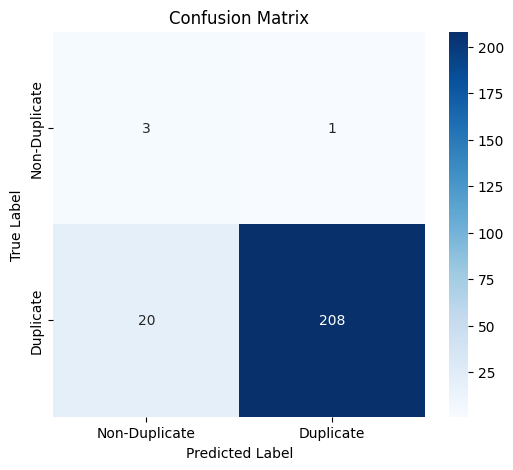

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Duplicate","Duplicate"],
    yticklabels=["Non-Duplicate","Duplicate"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def get_embedding(image_path):

    image = Image.open(image_path).convert("RGB")

    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = model.forward_once(image)

    return embedding.cpu().numpy()

In [ ]:
query_image = image_paths[0]   # you can change index

In [ ]:
query_embedding = get_embedding(query_image)

In [ ]:
k = 6  # query + 5 similar images

distances, indices = index.search(query_embedding, k)

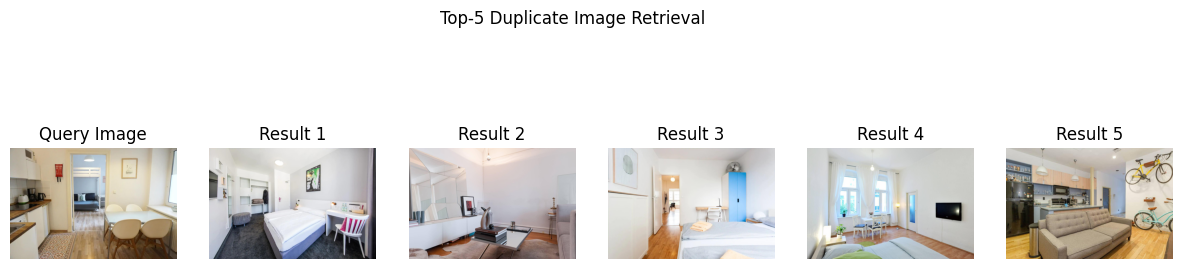

In [ ]:
plt.figure(figsize=(15,4))

# show query image
plt.subplot(1,6,1)
plt.imshow(Image.open(query_image))
plt.title("Query Image")
plt.axis("off")

# show retrieved images
for i in range(1,6):

    retrieved_path = image_paths[indices[0][i]]

    plt.subplot(1,6,i+1)

    plt.imshow(Image.open(retrieved_path))

    plt.title(f"Result {i}")

    plt.axis("off")

plt.suptitle("Top-5 Duplicate Image Retrieval")

plt.show()